In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_squared_error, mean_absolute_error
# Génère 1000 heures de trafic Internet simulé
np.random.seed(42)
traffic = 500 + 50 * np.sin(np.arange(1000) * 2 * np.pi / 24) + 20 * np.random.randn(1000)

# Crée le DataFrame
df = pd.DataFrame({
    "hour": pd.date_range(start="2023-01-01", periods=1000, freq="H"),
    "traffic": traffic
})

# Sauvegarde le fichier CSV
df.to_csv("internet_traffic.csv", index=False)

print("✅ Fichier 'internet_traffic.csv' généré.")


✅ Fichier 'internet_traffic.csv' généré.


/tmp/ipython-input-21-636476012.py:11: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  "hour": pd.date_range(start="2023-01-01", periods=1000, freq="H"),


Ce bloc importe les bibliothèques nécessaires pour le traitement des données, la visualisation, et la construction d'un modèle LSTM. Pandas et NumPy gèrent les données, Matplotlib les visualise, et Keras fournit les outils pour le modèle LSTM.

In [ ]:
# Maintenant, ce code fonctionnera
data = pd.read_csv("internet_traffic.csv")
print(data.head())

                  hour     traffic
0  2023-01-01 00:00:00  509.934283
1  2023-01-01 01:00:00  510.175666
2  2023-01-01 02:00:00  537.953771
3  2023-01-01 03:00:00  565.815936
4  2023-01-01 04:00:00  538.618203


Ce bloc charge les données de trafic Internet à partir d’un fichier CSV. Cela permet de récupérer les séries temporelles contenant le nombre de connexions.

In [ ]:
# Exemple de chargement depuis un fichier CSV (à adapter)
# Si tu n'as pas de fichier, je peux t'en générer un
data = pd.read_csv("internet_traffic.csv")

# On suppose qu'on a une colonne 'traffic' avec le nombre de connexions par heure
print(data.head())

traffic = data['traffic'].values.reshape(-1, 1)
print(traffic)


                  hour     traffic
0  2023-01-01 00:00:00  509.934283
1  2023-01-01 01:00:00  510.175666
2  2023-01-01 02:00:00  537.953771
3  2023-01-01 03:00:00  565.815936
4  2023-01-01 04:00:00  538.618203
[[509.93428306]
 [510.17566623]
 [537.95377076]
 [565.81593619]
 [538.61820269]
 [543.61355218]
 [581.58425631]
 [563.6449859 ]
 [533.91178247]
 [546.20653993]
 [515.73164614]
 [503.62635718]
 [504.83924543]
 [448.79344285]
 [440.50164335]
 [453.39891036]
 [436.4421074 ]
 [457.98865534]
 [431.83951849]
 [423.45763466]
 [486.01170519]
 [460.12913493]
 [476.35056409]
 [458.56408402]
 [489.11234551]
 [515.15940405]
 [501.98012845]
 [542.86929943]
 [531.28849639]
 [542.46241632]
 [537.96586776]
 [585.341855  ]
 [543.03132569]
 [514.20112048]
 [541.45089824]
 [488.52407926]
 [504.1772719 ]
 [447.86564527]
 [448.43627902]
 [468.58188566]
 [471.46806141]
 [455.13107431]
 [447.68703435]
 [445.68163477]
 [427.12829   ]
 [450.24777677]
 [465.78722458]
 [508.20149227]
 [506.87236579]
 [477.

📊 Ce bloc charge les données de trafic Internet à partir d’un fichier CSV. Cela permet de récupérer les séries temporelles contenant le nombre de connexions.

In [ ]:
scaler = MinMaxScaler()
scaled = scaler.fit_transform(traffic)

print(scaled)

[[0.53827473]
 [0.53949236]
 [0.67961521]
 [0.82016209]
 [0.68296684]
 [0.7081652 ]
 [0.89970323]
 [0.80921103]
 [0.65922595]
 [0.72124517]
 [0.56751874]
 [0.50645526]
 [0.51257351]
 [0.22985812]
 [0.18803127]
 [0.25308977]
 [0.1675535 ]
 [0.27624211]
 [0.14433637]
 [0.1020551 ]
 [0.41760056]
 [0.28703947]
 [0.36886625]
 [0.27914478]
 [0.43324131]
 [0.56463214]
 [0.49815109]
 [0.70441092]
 [0.64599314]
 [0.70235845]
 [0.67967623]
 [0.91865792]
 [0.70522824]
 [0.55979821]
 [0.69725599]
 [0.43027389]
 [0.50923428]
 [0.22517797]
 [0.22805646]
 [0.32967822]
 [0.34423713]
 [0.26182744]
 [0.22427699]
 [0.21416103]
 [0.12057122]
 [0.23719431]
 [0.31558093]
 [0.52953391]
 [0.52282931]
 [0.37557316]
 [0.64696763]
 [0.62765788]
 [0.63829713]
 [0.79349699]
 [0.84439549]
 [0.82574094]
 [0.62192358]
 [0.63531218]
 [0.64769194]
 [0.65186154]
 [0.43982002]
 [0.40415311]
 [0.25043841]
 [0.18913541]
 [0.35170877]
 [0.38136591]
 [0.22867953]
 [0.34578225]
 [0.30621973]
 [0.24473306]
 [0.39851373]
 [0.57

Ce bloc normalise les données entre 0 et 1 à l’aide de MinMaxScaler. C’est une étape essentielle pour optimiser les performances du modèle LSTM.

In [ ]:
def create_sequences(data, seq_len=24):  # par ex., 24 heures
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

seq_length = 24
X, y = create_sequences(scaled, seq_length)


Ce bloc définit une fonction pour transformer les séries temporelles en séquences supervisées. Chaque entrée est une séquence de pas de temps, et chaque sortie est la valeur suivante.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

Ce bloc divise les données en deux ensembles : entraînement et test. Cela permet d’évaluer la performance du modèle sur des données non vues.

In [ ]:
model = Sequential([
    LSTM(64, activation='tanh', input_shape=(seq_length, 1)),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

Ce bloc construit le modèle LSTM avec des couches empilées : LSTM, Dropout (régularisation) et Dense. Le modèle apprend à prédire le trafic à partir de séquences de valeurs précédentes.

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.1053 - mae: 0.2711 - val_loss: 0.0440 - val_mae: 0.1742
Epoch 2/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0395 - mae: 0.1670 - val_loss: 0.0360 - val_mae: 0.1589
Epoch 3/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0337 - mae: 0.1547 - val_loss: 0.0286 - val_mae: 0.1404
Epoch 4/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0230 - mae: 0.1251 - val_loss: 0.0155 - val_mae: 0.1005
Epoch 5/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0155 - mae: 0.0976 - val_loss: 0.0105 - val_mae: 0.0825
Epoch 6/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0140 - mae: 0.0947 - val_loss: 0.0105 - val_mae: 0.0824
Epoch 7/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0126 - mae: 0.0886 - val_loss: 0.0102 - val_mae: 0.0807
Epoch 8/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0125 - mae: 0.0887 - val_loss: 0.0107 - val_mae: 0.0818
Epoch 9/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0120 

Ce bloc entraîne le modèle sur les données d'entraînement. Le modèle ajuste ses poids à chaque époque pour minimiser l'erreur de prédiction.

In [ ]:
pred = model.predict(X_test)

# Dénormalisation
pred_traffic = scaler.inverse_transform(pred)
true_traffic = scaler.inverse_transform(y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


Ce bloc utilise le modèle entraîné pour prédire les valeurs de trafic sur l’ensemble de test. Ces prédictions peuvent ensuite être comparées aux vraies valeurs.

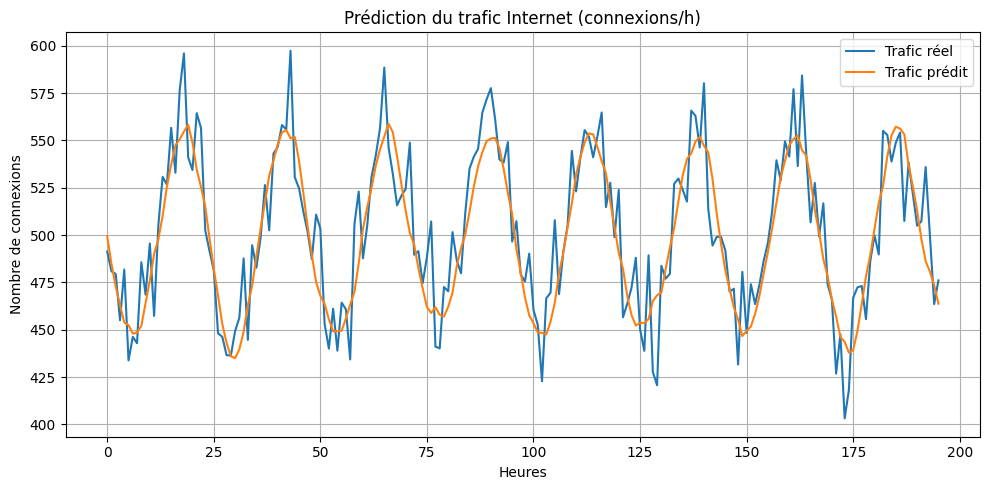

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(true_traffic, label='Trafic réel')
plt.plot(pred_traffic, label='Trafic prédit')
plt.title('Prédiction du trafic Internet (connexions/h)')
plt.xlabel('Heures')
plt.ylabel('Nombre de connexions')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Ce bloc trace l’évolution du trafic au fil du temps. Cela permet de visualiser les tendances et la nature temporelle des données.

In [ ]:
# Dénormalisation si ce n’est pas encore fait
pred_traffic = scaler.inverse_transform(pred)
true_traffic = scaler.inverse_transform(y_test)

# Calcul des erreurs
mse = mean_squared_error(true_traffic, pred_traffic)
rmse = np.sqrt(mse)
mae = mean_absolute_error(true_traffic, pred_traffic)

# Affichage
print("✅ Erreurs entre la valeur réelle et la valeur prédite :")
print(f" - MSE  (Mean Squared Error)      : {mse:.2f}")
print(f" - RMSE (Root Mean Squared Error) : {rmse:.2f}")
print(f" - MAE  (Mean Absolute Error)     : {mae:.2f}")


✅ Erreurs entre la valeur réelle et la valeur prédite :
 - MSE  (Mean Squared Error)      : 404.69
 - RMSE (Root Mean Squared Error) : 20.12
 - MAE  (Mean Absolute Error)     : 15.96


Ce bloc transforme les valeurs normalisées prédites et réelles en valeurs d’origine (non normalisées) pour les comparer visuellement ou les analyser plus facilement.

/tmp/ipython-input-32-1407075392.py:11: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


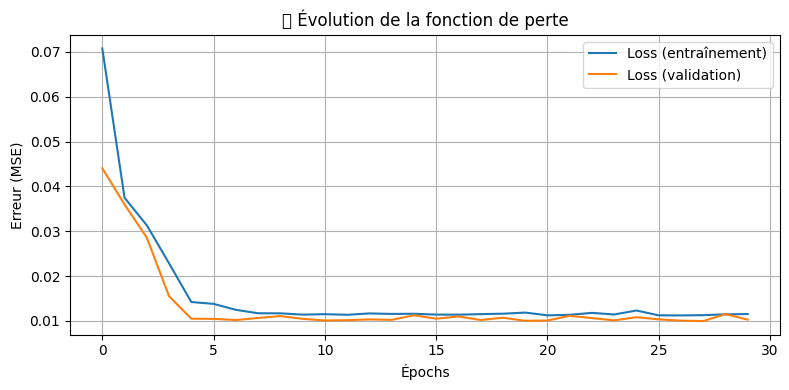

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Loss (entraînement)')
plt.plot(history.history['val_loss'], label='Loss (validation)')
plt.title('📉 Évolution de la fonction de perte')
plt.xlabel('Épochs')
plt.ylabel('Erreur (MSE)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Ce bloc trace l’évolution du trafic au fil du temps. Cela permet de visualiser les tendances et la nature temporelle des données.